In [ ]:
# Install dependencies (uncomment line below)
# %pip install -r ../../requirements.txt

# Load the required modules
import os
import scvi
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import plotnine as p9
import warnings
import anndata as ad
import celltypist
import time
import matplotlib.pyplot as plt
import scanpy.external as sce
from scipy import sparse
from scipy.sparse import csr_matrix
from scipy.stats import median_abs_deviation
from scipy.spatial.distance import jensenshannon
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from kneed import KneeLocator as kl
import plotnine as p9
import warnings
import anndata as ad
import celltypist
import time
from celltypist import models
# Ignore the warning messages
warnings.filterwarnings("ignore")


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


This notebook implements a supervised validation pipeline in which a CellTypist classifier is trained on real PDAC single-cell RNA-seq data and applied to a synthetic PDAC dataset generated by our scRNA-seq model.

### **Workflow**

1. **Real dataset preprocessing**

- Quality control filtering and normalization

- Selection of highly variable genes

- PCA with automatic elbow-based PC selection

- UMAP visualization

- Harmonization and simplification of cell-type labels

2. **Model training**

- Training CellTypist using curated real cell_type annotations

- Saving the trained classifier as a reusable reference model

3. **Synthetic dataset preparation**

- Loading and merging synthetic samples

- Verifying gene overlap with the real dataset

- Removing unwanted cell types and filtering outliers

- PCA and UMAP inspection (non-integrated visualization)

4. **Synthetic data annotation**

- Applying the trained CellTypist model

- Refining predictions using majority voting

- Comparing predicted labels with internal annotations

- Visualizing results via dotplots and UMAP projections


The goal is to evaluate whether the synthetic PDAC data preserve biologically meaningful transcriptional programs. If a classifier trained exclusively on real data can accurately recover cell types in the synthetic dataset, this supports the biological fidelity and structural realism of the generative model.

In [ ]:
# ----------------------------------------------------------------------------------
# PCA_Elbow_fit
# ----------------------------------------------------------------------------------
# This function determines the optimal number of principal components (PCs)
# using an elbow (knee) detection algorithm applied to the explained variance
# curve obtained from PCA.
#
# Steps:
# 1. Perform PCA on the full dataset.
# 2. Extract the explained variance ratio for each component.
# 3. Apply a knee detection algorithm to identify the point where additional
#    PCs contribute marginal gains in explained variance.
# 4. Recompute PCA using only the selected number of components.
#
# Returns:
# - pcs_used: optimal number of PCs (capped at 50 if larger).
# - new_data: data projected into the reduced PC space.
# - pcs: list of all PC indices.
# - explained_variance: explained variance ratio per PC.
# - pc_list: list of selected PC indices.
# ----------------------------------------------------------------------------------

def PCA_Elbow_fit(data):
    model = PCA().fit(data)
    explained_variance = model.explained_variance_ratio_
    pcs = list(range(1, explained_variance.shape[0]+1))#enumerate(explained_variance,1)
    klm = kl(pcs, explained_variance, S=1.0, curve='convex', direction='decreasing')
    pcs_used = klm.knee
    pc_list = list(range(1, pcs_used+1))
    new_data = PCA(n_components= pcs_used, svd_solver='arpack').fit_transform(data)

    if pcs_used >50:
        pcs_used=50

    return pcs_used, new_data, pcs, explained_variance, pc_list

#### REAL DATA FOR TRAINING CellTypist Model

In [3]:
# Load annotated scRNA-seq dataset (raw counts with predefined cell type labels)
adata_lin= sc.read_h5ad("/home/app/datos/Kim/adata_anotado_raw_5_clusters.h5ad")

In [4]:
adata_lin

AnnData object with n_obs × n_vars = 32349 × 7028
    obs: 'Sample', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'cohort', 'cell_type'

In [5]:
adata_lin.X.max(),adata_lin.X.min()

(11414.0, 0.0)

In [6]:
# Quality control filtering

# Remove low-quality cells (fewer than 200 detected genes)
sc.pp.filter_cells(adata_lin, min_genes=200)
# Remove genes detected in fewer than 3 cells
sc.pp.filter_genes(adata_lin, min_cells=3)
# Normalize each cell to a fixed library size (10,000 counts per cell)
sc.pp.normalize_total(adata_lin, target_sum = 1e4)
# Log-transform normalized counts to stabilize variance
sc.pp.log1p(adata_lin)

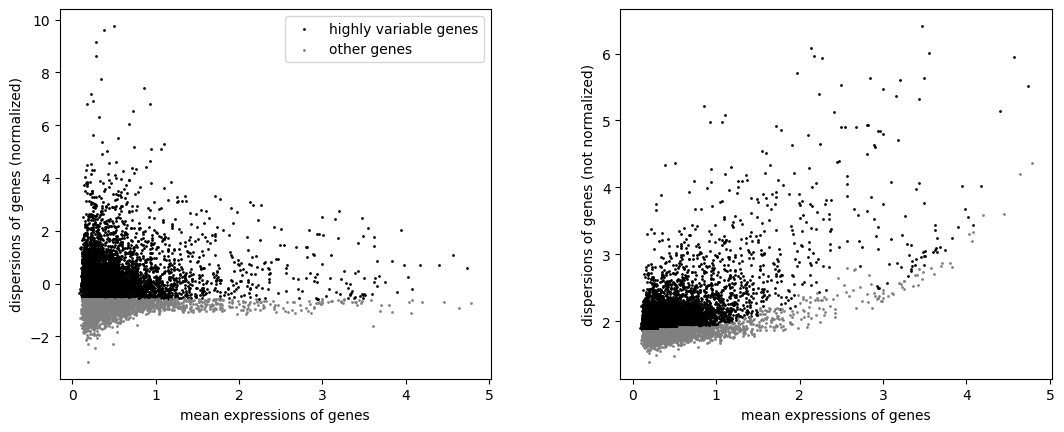

In [ ]:
# Select and compute highly variable genes
sc.pp.highly_variable_genes(adata_lin,n_top_genes=5000)

# Plot variable genes
sc.pl.highly_variable_genes(adata_lin)

# Subset the dataset to retain only HVGs
adata_lin = adata_lin[:, adata_lin.var.highly_variable].copy()

In [9]:
# Compute PCA to capture major axes of variation
sc.tl.pca(adata_lin, svd_solver='arpack')
# Convert sparse matrix to dense format for compatibility with sklearn PCA
adata_lin.X = adata_lin.X.todense()

In [11]:
#Convert AnnData matrix to pandas DataFrame
new_frame = pd.DataFrame(adata_lin.X,
                         index=adata_lin.obs_names,
                         columns=adata_lin.var_names)

# Extract numpy array for elbow-based PCA fitting
pandas_data = new_frame.values
# Determine optimal dimensionality using elbow detection
dim, new_matrix, pc_ax, pc_ay, col_labels = PCA_Elbow_fit(pandas_data)
print(dim)

50


2026-02-19 15:25:58.564301: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771514758.578455    2555 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771514758.582635    2555 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771514758.593949    2555 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771514758.593973    2555 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771514758.593975    2555 computation_placer.cc:177] computation placer alr

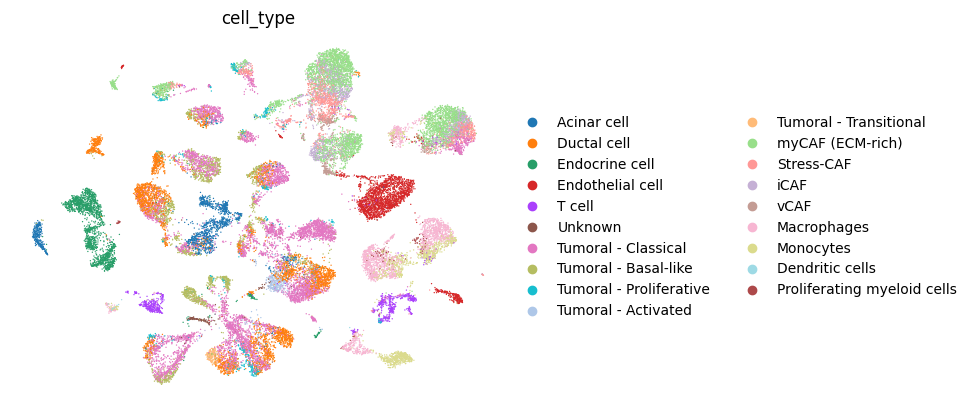

In [12]:
# Neigbours computation and umap
sc.pp.neighbors(adata_lin, n_pcs = dim) # compute nearest neighbors
# Compute UMAP embedding
sc.tl.umap(adata_lin)
# Plot UMAP
sc.pl.umap(adata_lin, color = ['cell_type'], frameon = False)

In [13]:
# Simplification of tumoral cell subtypes

# Group multiple tumor subtypes under a single label
tumoral_types = ["Tumoral - Activated", "Tumoral - Classical", "Tumoral - Basal-like", "Tumoral - Transitional", "Tumoral - Proliferative"]  # los que quieras unificar
adata_lin.obs['cell_type'] = adata_lin.obs['cell_type'].replace(tumoral_types, "Tumoral cell")

In [14]:
# Simplification of fibroblast subtypes
tumoral_types = ["iCAF", "vCAF", "Stress-CAF", "myCAF (ECM-rich)"]  # los que quieras unificar
adata_lin.obs['cell_type'] = adata_lin.obs['cell_type'].replace(tumoral_types, "Tumoral Fibroblast")

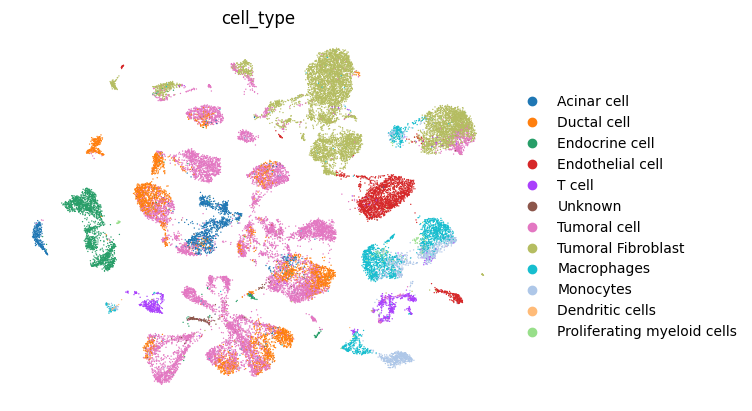

In [15]:
#UMAP projection of Lin's dataset
sc.pl.umap(adata_lin, color = ['cell_type'], frameon = False)

In [16]:
# Remove cell types not shared across datasets to improve annotation consistency
celltypes_to_remove_lin = ["Stellate"]
adata_lin = adata_lin[~adata_lin.obs["cell_type"].isin(celltypes_to_remove_lin), :].copy()

In [18]:
#########################################################################################################3

In [ ]:
# ---------------------------------------------------------------------------------
# Utility function to load multiple AnnData objects from a folder and merge them into
# a single AnnData container.
#
# - It scans the folder for files with a given extension (default: .h5ad)
# - Loads each file as an AnnData object
# - Concatenates all objects into one global AnnData
#
# Notes:
# - `label=batch_key` adds a batch/sample column to `.obs` indicating the source file
# - `join="outer"` keeps the union of genes across datasets (missing genes are filled)
# - `fill_value=0` assigns 0 to genes not present in a given dataset
# ----------------------------------------------------------------------------------
def load_and_merge(folder, filetype=".h5ad", batch_key="Sample"):
    adatas = []
    fnames = [f for f in os.listdir(folder) if f.endswith(filetype)]
    fnames.sort()

    for fname in fnames:
        path = os.path.join(folder, fname)
        print(f"Cargando {path}")
        adata = sc.read(path)
        mask = np.array((adata.X.max(axis=1) <= 9.22)).flatten()
        adata_filtered = adata[mask].copy()

        adatas.append(adata_filtered)

    adata_global = ad.concat(adatas, join="outer", label=batch_key, fill_value=0)
    return adata_global


#### SYNTHETIC DATA FOR CELL TYPE PREDICTION

In [59]:
# Load and merge all .h5ad files from the synthetic folder into a single AnnData object
adata_peng = load_and_merge("datos_octubre")

# Basic sanity checks: object summary and number of cells per sample/batch
print(adata_peng)
print(adata_peng.obs["Sample"].value_counts())
# Add a simple synthetic flag
adata_peng.obs["cell_origin"] = "synthetic"

Cargando datos_octubre/Acinar cell_cholesky.h5ad
Cargando datos_octubre/B cell_cholesky.h5ad
Cargando datos_octubre/CAF_cholesky.h5ad
Cargando datos_octubre/Dendritic cells_cholesky.h5ad
Cargando datos_octubre/Ductal cell_cholesky.h5ad
Cargando datos_octubre/Endocrine cells_cholesky.h5ad
Cargando datos_octubre/Endothelial cells_cholesky.h5ad
Cargando datos_octubre/Fibroblast_cholesky.h5ad
Cargando datos_octubre/Macrophages_cholesky.h5ad
Cargando datos_octubre/Mast cells_cholesky2.h5ad
Cargando datos_octubre/Monocytes_cholesky.h5ad
Cargando datos_octubre/Plasma cells_cholesky.h5ad
Cargando datos_octubre/Proliferative cells_cholesky.h5ad
Cargando datos_octubre/Ribosomal cells_cholesky.h5ad
Cargando datos_octubre/T CD4 Reg_cholesky.h5ad
Cargando datos_octubre/T CD4_cholesky.h5ad
Cargando datos_octubre/T CD8_cholesky.h5ad
Cargando datos_octubre/Tumoral - Basal-like_cholesky.h5ad
Cargando datos_octubre/Tumoral - Classical_cholesky.h5ad
AnnData object with n_obs × n_vars = 45830 × 3000
    o

In [23]:
# Remove cell types not shared across datasets to improve annotation consistency
celltypes_to_remove_peng = ["Proliferative cells Cholesky", "Ribosomal cells Cholesky"]
adata_peng = adata_peng[~adata_peng.obs["cell_type"].isin(celltypes_to_remove_peng), :].copy()

In [60]:
# Compare gene names across datasets (case-insensitive)
# -------------------------------------------------------
# This is a quick diagnostic to verify that datasets share a substantial
# fraction of genes before attempting  analysis.

genes1 = set(g.lower() for g in adata_lin.var_names)
genes2 = set(g.lower() for g in adata_peng.var_names)

shared_genes = genes1 & genes2
print(f"Number of shared genes: {len(shared_genes)}")

Number of shared genes: 590


In [ ]:
# Run PCA to capture major axes of variation.
sc.tl.pca(adata_peng, svd_solver="arpack")
# Convert expression matrix into a numpy array for the elbow fitting function
new_frame = pd.DataFrame(adata_peng.X, index=adata_peng.obs_names, columns=adata_peng.var_names)
pandas_data = new_frame.values
# Estimate optimal number of PCs using the elbow/knee criterion
dim, new_matrix, pc_ax, pc_ay, col_labels = PCA_Elbow_fit(pandas_data)
print(dim)
sc.tl.pca(adata_peng, svd_solver='arpack')

In [29]:
# Execute PCA elbow_fitting_funcion
dim,new_matrix,pc_ax,pc_ay,col_labels=PCA_Elbow_fit(pandas_data)
print(dim)

50


... storing 'cell_origin' as categorical


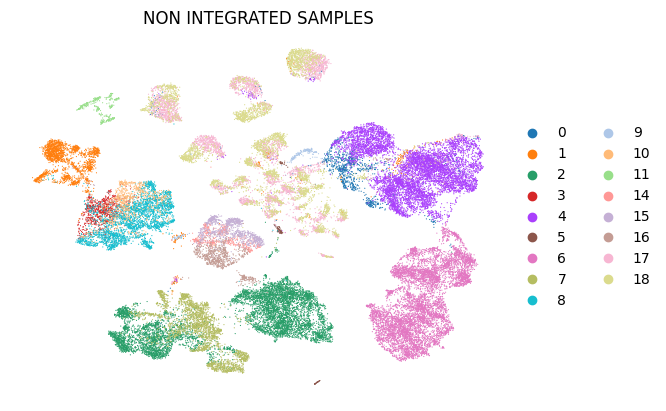

In [ ]:
# Neigbours computation and umap
sc.pp.neighbors(adata_peng, n_pcs = dim)
# Compute UMAP embedding
sc.tl.umap(adata_peng)

# Plot UMAP
sc.pl.umap(adata_peng, color = ['Sample'], frameon = False,title="NON INTEGRATED SAMPLES")

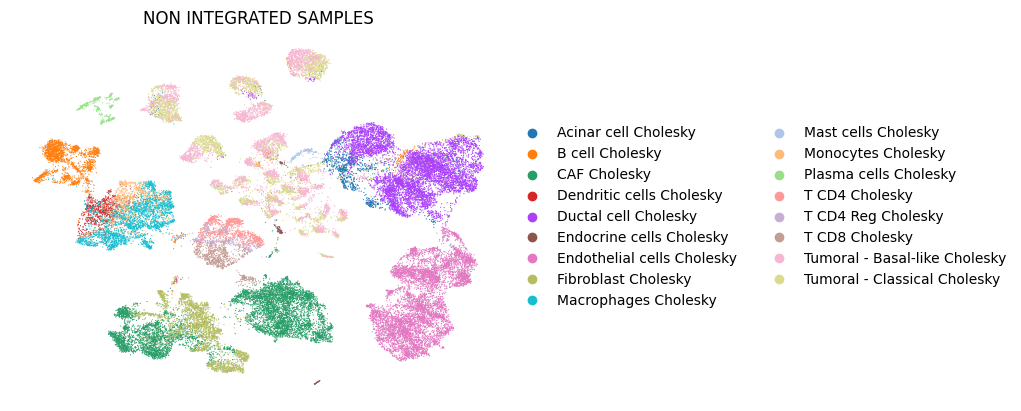

In [31]:
sc.pl.umap(adata_peng, color = ['cell_type'], frameon = False,title="NON INTEGRATED SAMPLES")

In [34]:
# Collapse specific tumor subtypes into a single "Tumoral cell" label
tumoral_types = ["Tumoral - Classical Cholesky", "Tumoral - Basal-like Cholesky"]  # los que quieras unificar

adata_peng.obs['cell_type'] = adata_peng.obs['cell_type'].replace(tumoral_types, "Tumoral cell")

In [35]:
# Remove the " Cholesky" suffix from all remaining cell type names
adata_peng.obs["cell_type"] = (
    adata_peng.obs["cell_type"]
    .astype(str)               # por si no está en string
    .str.replace(" Cholesky", "", regex=False)
)

# Convert back to categorical for cleaner category handling downstream
adata_peng.obs["cell_type"] = pd.Categorical(adata_peng.obs["cell_type"])

In [36]:
adata_peng.obs.cell_type.unique()

['Acinar cell', 'B cell', 'CAF', 'Dendritic cells', 'Ductal cell', ..., 'Plasma cells', 'T CD4 Reg', 'T CD4', 'T CD8', 'Tumoral cell']
Length: 16
Categories (16, object): ['Acinar cell', 'B cell', 'CAF', 'Dendritic cells', ..., 'T CD4', 'T CD4 Reg', 'T CD8', 'Tumoral cell']

In [ ]:
############################################################################################################################################################

In [42]:
# Convert expression matrix to a NumPy array.
# CellTypist expects a dense matrix; this avoids sparse-format compatibility issues.
adata_lin.X = np.asarray(adata_lin.X)

In [43]:
# -------------------------------------------------------
# Train CellTypist model on annotated real dataset
# -------------------------------------------------------
# - 'cell_type' is used as the reference annotation.
# - check_expression=False bypasses internal gene expression validation,
#   which is useful when training on a subset of genes (e.g., HVGs only).
# - n_jobs controls parallelization.
# - max_iter sets the maximum number of training iterations.t_start = time.time()

model = celltypist.train(adata_lin, 'cell_type', check_expression = False, n_jobs = 10, max_iter = 100)
t_end = time.time()
print(f"Time elapsed: {(t_end - t_start)/60} minutes")

🍳 Preparing data before training
🔬 Input data has 31728 cells and 5000 genes
⚖️ Scaling input data
🏋️ Training data using logistic regression
/env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
✅ Model training done!


Time elapsed: 0.6027420878410339 minutes


In [44]:
# Save the model.
model.write('model_from_lim.pkl')

In [45]:
# Ensure that cell barcodes are unique (required for downstream merging and plotting)
adata_lin.obs_names _make_unique()
adata_peng.obs_names_make_unique()

In [49]:
# CellTypist prediction without over-clustering and majority-voting.
t_start = time.time()
predictions = celltypist.annotate(adata_filtered, model = 'model_from_lim.pkl', majority_voting = True)
t_end = time.time()
print(f"Time elapsed: {t_end - t_start} seconds")

⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 43786 cells and 3000 genes
🔗 Matching reference genes in the model
🧬 590 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 20
🗳️ Majority voting the predictions
✅ Majority voting done!


Time elapsed: 26.970492839813232 seconds


In [50]:
# Extract predicted labels (raw and majority-voted)
predictions.predicted_labels

,predicted_labels,over_clustering,majority_voting
0,Acinar cell,153,Acinar cell
1,Endothelial cell,244,Ductal cell
2,Acinar cell,153,Acinar cell
3,Tumoral cell,52,Tumoral cell
4,Acinar cell,97,Acinar cell
...,...,...,...
4128-4,Endothelial cell,251,Endothelial cell
4129-4,Tumoral cell,224,Tumoral cell
4130-4,Tumoral cell,28,Tumoral cell
4131-4,Endothelial cell,114,Endothelial cell


In [51]:
predictions

CellTypist prediction result for 43786 query cells
    predicted_labels: data frame with 3 columns ('predicted_labels', 'over_clustering', 'majority_voting')
    decision_matrix: data frame with 43786 query cells and 12 cell types
    probability_matrix: data frame with 43786 query cells and 12 cell types
    adata: AnnData object referred

In [52]:
# Update matplotlib plotting parameters for clearer visualization
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 5,
    'ytick.labelsize': 5,
    'legend.frameon' : False
})

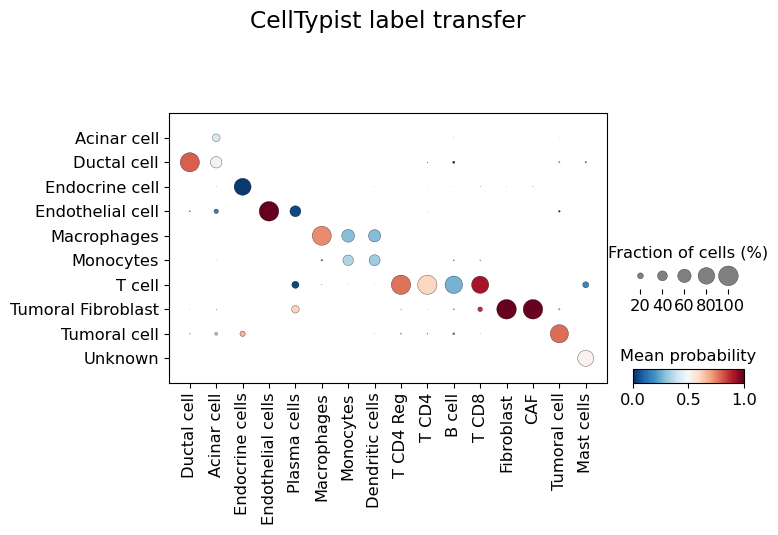

In [53]:
# Compare original annotations vs predicted labels
# - use_as_reference: ground-truth labels
# - use_as_prediction: model output (majority_voting or predicted_labels)
# The dotplot visualizes agreement between manual annotation and model prediction.
celltypist.dotplot(predictions, use_as_reference = 'cell_type', use_as_prediction = 'majority_voting', save= "CellTypist_buble")

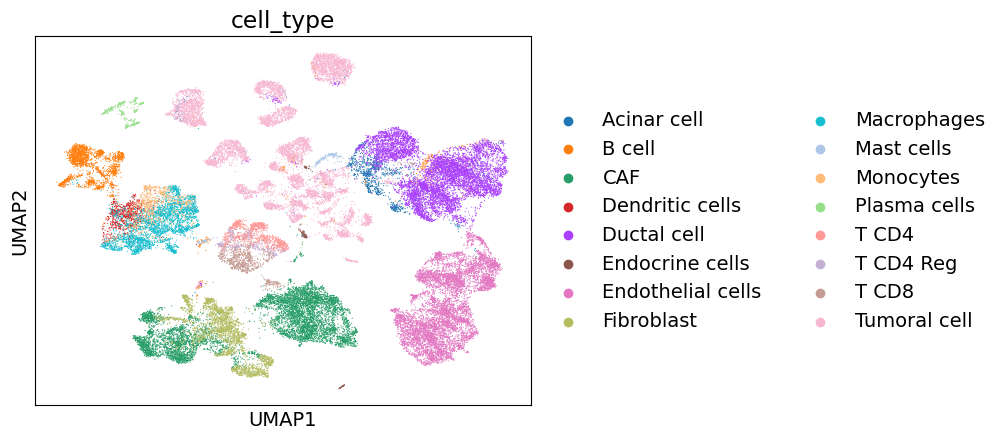

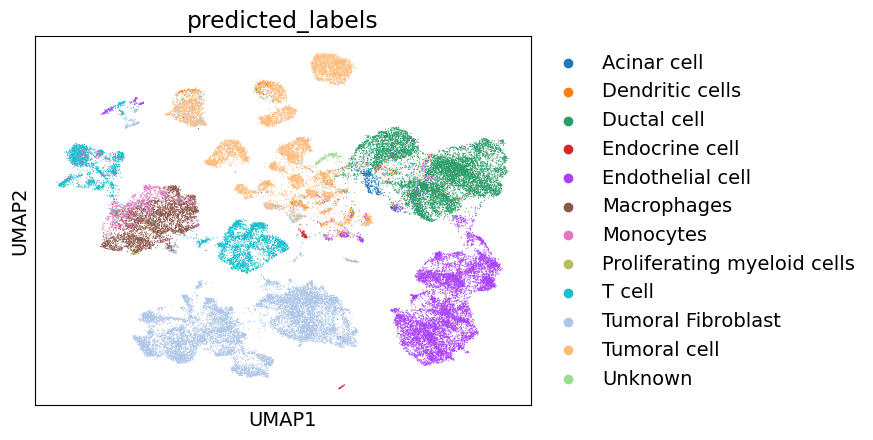

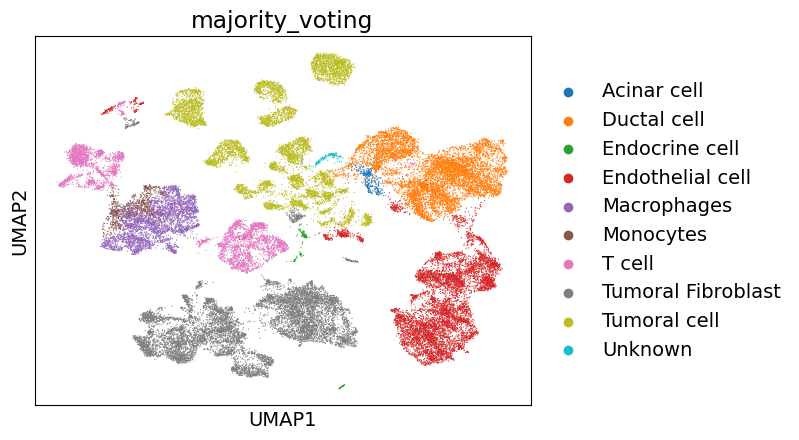

In [62]:
# Convert predictions object back to AnnData for visualization
adata = predictions.to_adata()

# UMAP colored by original labels
sc.pl.umap(adata, color=['cell_type'], save="real")

# UMAP colored by raw predicted labels
sc.pl.umap(adata, color=['predicted_labels'], save="predicted_labels")

# UMAP colored by majority-voted predictions
sc.pl.umap(adata, color=['majority_voting'], save="major_voting")